# 1. Import and Preprocessing

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None) # show all columns
pd.set_option('display.width', 1000)

import os
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)



from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.tree import plot_tree

from xgboost import XGBClassifier


from sklearn import metrics   #Additional scklearn functions
from sklearn.model_selection import GridSearchCV

data_dir = ''

In [2]:
def preprocess_train(df):
    ## Rename columns
    col_names = {
        'id':'id',
        'Age':'age',
        'Sex':'sex',
        'Chest pain type':'chest_pain_type',
        'BP':'bp',
        'Cholesterol':'cholesterol',
        'FBS over 120':'fbs_over_120',
        'EKG results':'ekg_results',
        'Max HR':'max_hr',
        'Exercise angina':'exercise_angina',
        'ST depression':'st_depression',
        'Slope of ST':'slope_of_st',
        'Number of vessels fluro':'number_of_vessels_fluro',
        'Thallium':'thallium',
        'Heart Disease':'heart_disease'
    }

    df = df.rename(columns=col_names)

    ## Recode target variable column to binary
    df['heart_disease'] = df['heart_disease'].replace({'Presence':1, 'Absence':0}).astype(int)


    ## Drop id column
    drop_cols = ['id']
    df = df.drop(columns=drop_cols)
    return df

def preprocess_test(df):
    ## Rename columns
    col_names = {
        'id':'id',
        'Age':'age',
        'Sex':'sex',
        'Chest pain type':'chest_pain_type',
        'BP':'bp',
        'Cholesterol':'cholesterol',
        'FBS over 120':'fbs_over_120',
        'EKG results':'ekg_results',
        'Max HR':'max_hr',
        'Exercise angina':'exercise_angina',
        'ST depression':'st_depression',
        'Slope of ST':'slope_of_st',
        'Number of vessels fluro':'number_of_vessels_fluro',
        'Thallium':'thallium',
    }

    df = df.rename(columns=col_names)

    ## Recode target variable column to binary
    # df['heart_disease'] = df['heart_disease'].replace({'Presence':1, 'Absence':0}).astype(int)


    ## Drop id column
    # drop_cols = ['id']
    # df = df.drop(columns=drop_cols)
    return df

In [3]:
df = pd.read_csv(os.path.join(data_dir, 'train.csv'))
df = preprocess_train(df)

df_test = pd.read_csv(os.
path.join(data_dir, 'test.csv'))
df_test = preprocess_test(df_test)

df.head()

,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [4]:
df_test.head()

,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


## Data Partitioning

In [4]:
dep_var_name = 'heart_disease'


X = df.drop([dep_var_name], axis=1)
y = df[dep_var_name]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline Testing

Dont need to mess with categorical features since they've been encoded already

In [5]:
features_cat = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results', 'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']
features_num = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression']

numeric_transformer = Pipeline(steps = [
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, features_num)
    ]
)


In [14]:
model1 = LogisticRegression(solver='liblinear',random_state=42)


param_optimal = {
    'learning_rate':0.1,
    'n_estimators':140,
    'max_depth':6,
    'min_child_weight':4,
    'gamma':0,
    'subsample':0.65,
    'colsample_bytree':0.75,
    'objective':'binary:logistic',
    'scale_pos_weight':1,
    'seed':42    
}

model2 = XGBClassifier(**param_optimal)

In [21]:
# p1 = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', model1)
# ])

p1 = Pipeline(steps=[
    ('model', model2)
])

p2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model2)
]) 

In [28]:
m2_class = model2.fit(X_train, y_train).predict(X_test)
m2_auc = roc_auc_score(y_test, m2_class)

m2_auc

0.88517462302454

In [31]:
clf = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=6,
        min_child_weight=4, 
        gamma=0, 
        subsample=0.65, 
        colsample_bytree=0.75,
        objective= 'binary:logistic',
        # nthread=4,
        scale_pos_weight=1,
        seed=42,
        reg_alpha=1.5,
).fit(X_train, y_train)

clf_class = clf.predict(X_test)

clf_auc = roc_auc_score(y_test, clf_class)
clf_auc

0.8850726696934718

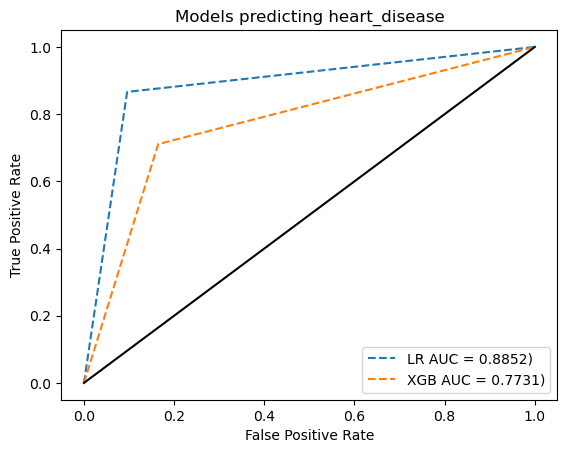

In [22]:
logit = p1.fit(X_train, y_train)
logit_class = logit.predict(X_test)

xgb = p2.fit(X_train, y_train)
xgb_class = xgb.predict(X_test)


logit_auc = roc_auc_score(y_test, logit_class)
xgb_auc = roc_auc_score(y_test, xgb_class)

logit_fpr, logit_tpr, _ = roc_curve(y_test, logit_class)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_class)

plt.plot(logit_fpr, logit_tpr, linestyle='--', label=f'LR AUC = {logit_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, linestyle='--', label=f'XGB AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='solid', c='k')

plt.title('Models predicting heart_disease')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# XGBoost optimization

https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/

https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

In [7]:
xgb = XGBClassifier(random_state=42, objective='binary:logistic').fit(X_train, y_train)
xgb_class = xgb.predict(X_test)

In [8]:
x0 = XGBClassifier(
    learning_rate =0.1,
    n_estimators=1000,
    max_depth=5,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective= 'binary:logistic',
    nthread=4,
    scale_pos_weight=1,
    seed=42
 ).fit(X_train, y_train)
x0_class = x0.predict(X_test)

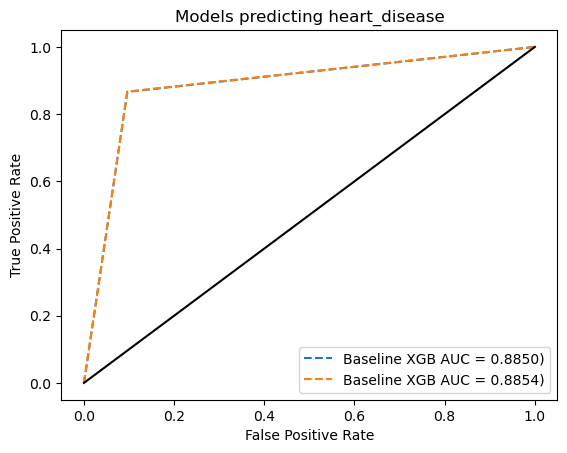

In [59]:
xgb_auc = roc_auc_score(y_test, xgb_class)
x0_auc = roc_auc_score(y_test, x0_class)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_class)
x0_fpr, x0_tpr, _ = roc_curve(y_test, x0_class)

plt.plot(xgb_fpr, xgb_tpr, linestyle='--', label=f'Baseline XGB AUC = {xgb_auc:.4f})')
plt.plot(x0_fpr, x0_tpr, linestyle='--', label=f'Baseline XGB AUC = {x0_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='solid', c='k')

plt.title('Models predicting heart_disease')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

### tuning max_depth and min_child_weight

In [ ]:
param_test1 = {
    'max_depth':range(3,10,2),
    'min_child_weight':range(1,6,2)
}

gs1 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=5,
        min_child_weight=1, 
        gamma=0, 
        subsample=0.8, 
        colsample_bytree=0.8,
        objective= 'binary:logistic',
        nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test1, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs1.fit(X_train, y_train)

print('Best Parameters', gs1.best_params_)
print('Best Score:', gs1.best_score_)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.8, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=0, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.1, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=5,
                                     max_leaves=None, min_child_weight=1,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=140,
                                     n_jobs=None, nthread=4, ...),
             param_grid={'max_depth': range(3, 10, 2),
                         'min_child_weight': range(1, 6, 2)},
             scoring='roc_auc')

In [ ]:
# print('Best Parameters', gs1.best_params_)
# print('Best Score:', gs1.best_score_)

Best Parameters {'max_depth': 7, 'min_child_weight': 5}
Best Score: 0.954998279182601


In [14]:
# since used interval of 2, look at one above and one below
param_test2 = {
    'max_depth':[6,7,8],
    'min_child_weight':[4,5,6]
}

gs2 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=5,
        min_child_weight=1, 
        gamma=0, 
        subsample=0.8, 
        colsample_bytree=0.8,
        objective= 'binary:logistic',
        nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test2, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs2.fit(X_train, y_train)

print('Best Parameters', gs2.best_params_)
print('Best Score:', gs2.best_score_)

Best Parameters {'max_depth': 6, 'min_child_weight': 4}
Best Score: 0.9550243148818878


### tuning gamma

In [ ]:
param_test3 = {
    'gamma':[i/10.0 for i in range(0,5)]
}

gs3 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=6,
        min_child_weight=4, 
        gamma=0, 
        subsample=0.8, 
        colsample_bytree=0.8,
        objective= 'binary:logistic',
        nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test3, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs3.fit(X_train, y_train)

print('Best Parameters', gs3.best_params_)
print('Best Score:', gs3.best_score_)

Best Parameters {'gamma': 0.0}
Best Score: 0.9550243148818878


### tuning subsample and colsample_bytree

In [16]:
param_test4 = {
    'subsample':[i/10.0 for i in range(6,10)],
    'colsample_bytree':[i/10.0 for i in range(6,10)]
}

gs4 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=6,
        min_child_weight=4, 
        gamma=0, 
        subsample=0.8, 
        colsample_bytree=0.8,
        objective= 'binary:logistic',
        nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test4, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs4.fit(X_train, y_train)

print('Best Parameters', gs4.best_params_)
print('Best Score:', gs4.best_score_)

Best Parameters {'colsample_bytree': 0.6, 'subsample': 0.8}
Best Score: 0.9551633234806765


In [17]:
# trying values in .05 intervals around the 0.6 and 0.8 optimums  
param_test5 = {
    'subsample':[i/100.0 for i in range(55,70, 5)],
    'colsample_bytree':[i/100.0 for i in range(75,90,5)]
}

gs5 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=6,
        min_child_weight=4, 
        gamma=0, 
        subsample=0.8, 
        colsample_bytree=0.8,
        objective= 'binary:logistic',
        nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test5, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs5.fit(X_train, y_train)

print('Best Parameters', gs5.best_params_)
print('Best Score:', gs5.best_score_)

Best Parameters {'colsample_bytree': 0.75, 'subsample': 0.65}
Best Score: 0.9550697411728439


### tuning regularization parameters

In [18]:
param_test6 = {
    'reg_alpha':[1e-5, 1e-2, 0.1, 1, 100]
}

gs6 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=6,
        min_child_weight=4, 
        gamma=0, 
        subsample=0.65, 
        colsample_bytree=0.75,
        objective= 'binary:logistic',
        nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test6, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs6.fit(X_train, y_train)

print('Best Parameters', gs6.best_params_)
print('Best Score:', gs6.best_score_)

Best Parameters {'reg_alpha': 1}
Best Score: 0.9550865089662055


In [23]:
param_test7 = {
    'reg_alpha':[0.5, .75, 1, 1.25, 1.5]
}

gs7 = GridSearchCV(
    estimator = XGBClassifier(
        learning_rate =0.1, 
        n_estimators=140, 
        max_depth=6,
        min_child_weight=4, 
        gamma=0, 
        subsample=0.65, 
        colsample_bytree=0.75,
        objective= 'binary:logistic',
        # nthread=4,
        scale_pos_weight=1,
        seed=42), 
    param_grid = param_test7, 
    scoring='roc_auc',
    # n_jobs=4,
    cv=5)

gs7.fit(X_train, y_train)

print('Best Parameters', gs7.best_params_)
print('Best Score:', gs7.best_score_)

Best Parameters {'reg_alpha': 1.5}
Best Score: 0.9550326479430773
